In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [30]:
img0 = cv2.imread("sphere0.png")
img1 = cv2.imread("sphere1.png")

In [31]:
img0_gray = cv2.cvtColor(img0, cv2.COLOR_BGR2GRAY)
img1_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)

In [32]:
harrisresponse = cv2.cornerHarris(np.float32(img0_gray),2,3,0.04)

In [33]:
corner_idx = harrisresponse > 0.01*harrisresponse.max()

In [20]:
corner_idx

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(200, 200))

In [35]:
y_coords, x_coords = np.where(corner_idx)
    
# (y, x)를 (x, y) 순서의 (N, 2) 배열로 결합
corners_to_track_xy = np.column_stack((x_coords, y_coords))

# LK 함수 입력 형식 (N, 1, 2) 및 float32로 변환
corners_to_track = corners_to_track_xy.astype(np.float32).reshape(-1, 1, 2)

lk_params = dict(
            winSize=(15, 15),
            maxLevel=2,
            criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03)
        )

p1, st, err = cv2.calcOpticalFlowPyrLK(
            img0_gray,
            img1_gray,
            corners_to_track, # 변환된 좌표 목록 사용
            None,
            **lk_params
        )

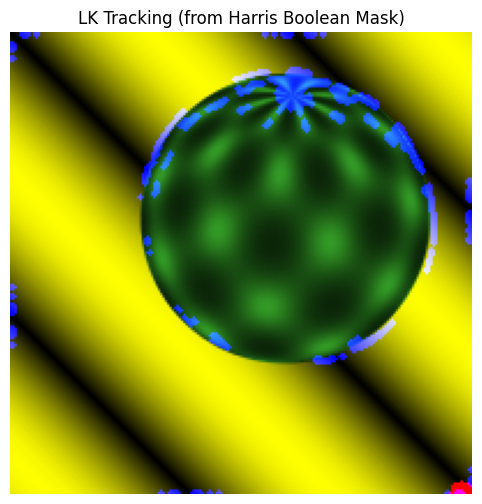

In [37]:
good_new = p1[st == 1]
good_old = corners_to_track[st == 1]

mask = np.zeros_like(img0)

for i, (new, old) in enumerate(zip(good_new, good_old)):
    a, b = int(new[0]), int(new[1])
    c, d = int(old[0]), int(old[1])
    
    mask = cv2.line(mask, (a, b), (c, d), (255, 0, 0), 2)
    # img0_bgr이 아닌 img1_bgr (두 번째 이미지)에 점을 찍어야 함
    # (실수 정정) 원본 코드를 img1_bgr로 수정합니다.
    img1_bgr_vis = cv2.imread("sphere1.png") # 시각화용 새 이미지 로드
    img1_bgr_vis = cv2.circle(img1_bgr_vis, (a, b), 5, (0, 0, 255), -1)
output_img = cv2.add(img1_bgr_vis, mask)
output_img_rgb = cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(output_img_rgb)
plt.title("LK Tracking (from Harris Boolean Mask)")
plt.axis('off')
plt.show()

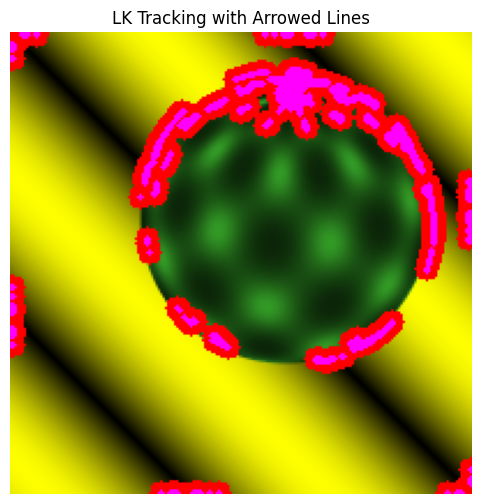

In [41]:
good_new = p1[st == 1]
good_old = corners_to_track[st == 1]

# 'mask' 생성 (img0_bgr과 동일한 크기)
mask = np.zeros_like(img0) 
for i, (new, old) in enumerate(zip(good_new, good_old)):
    a, b = int(new[0]), int(new[1])
    c, d = int(old[0]), int(old[1])
    
    # ⬇️ 이 부분을 수정했습니다 ⬇️
    # cv2.arrowedLine(이미지, 시작점(old), 끝점(new), 색상, 두께, 화살촉 길이 비율)
    mask = cv2.arrowedLine(mask, (c, d), (a, b), (255, 0, 0), 2, tipLength=0.1)
    
    # 새 위치(img1)에 점 그리기
    img1_bgr = cv2.circle(img1, (a, b), 5, (0, 0, 255), -1)
# --- 7. 이미지 합성 및 출력 ---
output_img = cv2.add(img1_bgr, mask)
output_img_rgb = cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(output_img_rgb)
plt.title("LK Tracking with Arrowed Lines")
plt.axis('off')
plt.show()

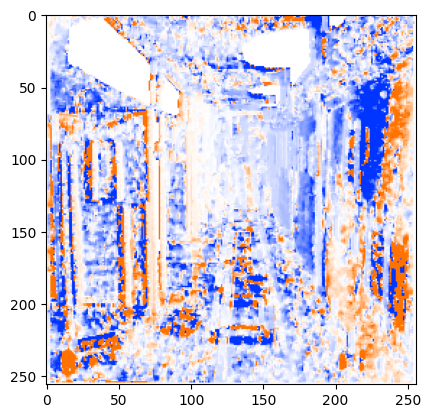

In [45]:
import numpy as np
import cv2
from scipy import signal
import matplotlib.pyplot as plt
import numpy as np

import flow_vis


def optical_flow(I1g, I2g, window_size):
    I1g = I1g / 255. # normalize pixels
    I2g = I2g / 255. # normalize pixels 

    kernel_x = np.array([[-1., 1.], [-1., 1.]])
    kernel_y = np.array([[-1., -1.], [1., 1.]])
    kernel_t = np.array([[1., 1.], [1., 1.]])#*.25
    
    fx = signal.convolve2d(I1g, kernel_x, boundary='symm', mode='same')
    fy = signal.convolve2d(I1g, kernel_y, boundary='symm', mode='same')
    ft = I1g - I2g

    # ft = signal.convolve2d(I2g, kernel_t, boundary='symm', mode=mode) + signal.convolve2d(I1g, -kernel_t, boundary='symm', mode=mode)
    
    u = np.zeros(I1g.shape)
    v = np.zeros(I1g.shape)

    w = window_size//2 # window_size is odd, all the pixels with offset in between [-w, w] are inside the window
    for i in range(w, I1g.shape[0]-w):
        for j in range(w, I1g.shape[1]-w):
            Ix = fx[i-w:i+w+1, j-w:j+w+1].flatten()
            Iy = fy[i-w:i+w+1, j-w:j+w+1].flatten()
            It = ft[i-w:i+w+1, j-w:j+w+1].flatten()

            b = np.reshape(It, (It.shape[0],1))
            A = np.vstack((Ix, Iy)).T

            U = np.matmul(np.linalg.pinv(A), b)     # Solving for (u,v) i.e., U

            u[i,j] = U[0][0]
            v[i,j] = U[1][0]
 
    return (u,v)



#   Read Input
# img1 = cv2.imread("./sphere0.png")
# img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)

# img2 = cv2.imread("./sphere1.png")
# img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
img1 = cv2.imread("./bt0.png", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("./bt1.png", cv2.IMREAD_GRAYSCALE)


# Obtain (u,v) from Lucas Kanade's optical flow approach
u, v = optical_flow( img1, img2, 3)

# print(U)

flow_color = flow_vis.flow_to_color(u, v, thr = 3)
plt.imshow(flow_color)
plt.show()

In [46]:
img1 = cv2.imread("./bt0.png", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("./bt1.png", cv2.IMREAD_GRAYSCALE)

img1.shape

(256, 256)

In [47]:
def wrap(u,v,img):
    flow = np.concatenate((npt.expand_dims(u,-1), np.expand_dims(v,-1)), axis = 2)
    flow = - flow
    h,w - flow.shape[:2]
    flow[:,:,0] += np.arange(w)
    flow[:,:,1] += np.arange(h)[:,np.newaxis]

    img = img.astype(np.float32)
    flow = flow.astype(np.float32)

    warpedImg = cv2.remap(img, flow, None, cv2.INTER_LINEAR)
    return warpedImg

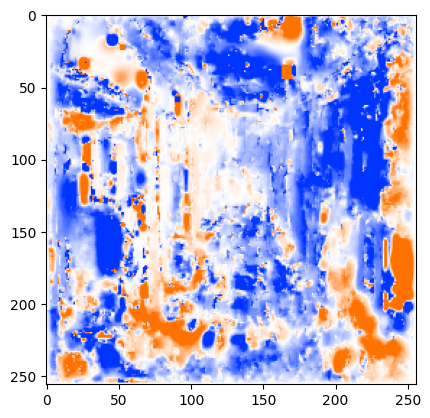

In [49]:
import numpy as np
import cv2
from scipy import signal
import matplotlib.pyplot as plt
import numpy as np

import flow_vis

def warp(u, v, img):
    
    flow = np.concatenate((np.expand_dims(u, -1), np.expand_dims(v, -1)), axis = 2)
    flow = -flow
    h, w = flow.shape[:2]
    flow[:,:,0] += np.arange(w)
    flow[:,:,1] += np.arange(h)[:,np.newaxis]
    
    img = img.astype(np.float32)
    flow = flow.astype(np.float32)
    
    warpedImg = cv2.remap(img, flow, None, cv2.INTER_LINEAR)
    return warpedImg
    



def optical_flow(I1g, I2g, window_size):

    

    I1g = I1g / 255. # normalize pixels
    I2g = I2g / 255. # normalize pixels 

    kernel_x = np.array([[-1., 1.], [-1., 1.]])
    kernel_y = np.array([[-1., -1.], [1., 1.]])
    kernel_t = np.array([[1., 1.], [1., 1.]])#*.25
    
    fx = signal.convolve2d(I1g, kernel_x, boundary='symm', mode='same')
    fy = signal.convolve2d(I1g, kernel_y, boundary='symm', mode='same')
    ft = I1g -I2g

    # ft = signal.convolve2d(I2g, kernel_t, boundary='symm', mode=mode) + signal.convolve2d(I1g, -kernel_t, boundary='symm', mode=mode)
    
    u = np.zeros(I1g.shape)
    v = np.zeros(I1g.shape)

    w = window_size//2 # window_size is odd, all the pixels with offset in between [-w, w] are inside the window
    for i in range(w, I1g.shape[0]-w):
        for j in range(w, I1g.shape[1]-w):
            Ix = fx[i-w:i+w+1, j-w:j+w+1].flatten()
            Iy = fy[i-w:i+w+1, j-w:j+w+1].flatten()
            It = ft[i-w:i+w+1, j-w:j+w+1].flatten()

            b = np.reshape(It, (It.shape[0],1))
            A = np.vstack((Ix, Iy)).T

            U = np.matmul(np.linalg.pinv(A), b)     # Solving for (u,v) i.e., U

            u[i,j] = U[0][0]
            v[i,j] = U[1][0]
 
    return (u,v)



#   Read Input
img1 = cv2.imread("./bt0.png", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("./bt1.png", cv2.IMREAD_GRAYSCALE)
h, w = img1.shape[:2]
w_8 = w//8
h_8 = h//8
w_4 = w//4
h_4 = h//4
w_2 = w//2
h_2 = h//2

scale = 8
img1_resized = cv2.resize(img1, dsize=(w_8, h_8), interpolation=cv2.INTER_CUBIC)
img2_resized = cv2.resize(img2, dsize=(w_8, h_8), interpolation=cv2.INTER_CUBIC)

# Obtain (u,v) from Lucas Kanade's optical flow approach
u, v = optical_flow(img1_resized, img2_resized, 3)

img1_resized = cv2.resize(img1, dsize=(w_4, h_4), interpolation=cv2.INTER_CUBIC)
img2_resized = cv2.resize(img2, dsize=(w_4, h_4), interpolation=cv2.INTER_CUBIC)

u = 2*cv2.resize(u, dsize=(w_4, h_4), interpolation=cv2.INTER_LINEAR)
v = 2*cv2.resize(v, dsize=(w_4, h_4), interpolation=cv2.INTER_LINEAR)
warpedImg = warp(u, v, img1_resized)
u_, v_ = optical_flow(warpedImg, img2_resized, 3)
u += u_
v += v_


img1_resized = cv2.resize(img1, dsize=(w_2, h_2), interpolation=cv2.INTER_CUBIC)
img2_resized = cv2.resize(img2, dsize=(w_2, h_2), interpolation=cv2.INTER_CUBIC)
u = 2*cv2.resize(u, dsize=(w_2, h_2), interpolation=cv2.INTER_LINEAR)
v = 2*cv2.resize(v, dsize=(w_2, h_2), interpolation=cv2.INTER_LINEAR)
warpedImg = warp(u, v, img1_resized)
u_, v_ = optical_flow(warpedImg, img2_resized, 3)
u += u_
v += v_


u = 2*cv2.resize(u, dsize=(w, h), interpolation=cv2.INTER_LINEAR)
v = 2*cv2.resize(v, dsize=(w, h), interpolation=cv2.INTER_LINEAR)
warpedImg = warp(u, v, img1)
u_, v_ = optical_flow(warpedImg, img2, 3)
u += u_
v += v_



# u = scale*cv2.resize(u, dsize=(w,h), interpolation=cv2.INTER_LINEAR)
# v = scale*cv2.resize(v, dsize=(w,h), interpolation=cv2.INTER_LINEAR)

# warpedImg = warp(u, v, img1)

# # u, v = optical_flow( img1, img2, 3)

# u_, v_ = optical_flow( warpedImg, img2, 3)
# u += u_
# v += v_


# print(U)

flow_color = flow_vis.flow_to_color(u, v, thr = 10)
plt.imshow(flow_color)
plt.show()